In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
data_train = datasets.EMNIST(root='data', split='letters', train=True, download=True, transform=transforms.ToTensor()) 
data_test = datasets.EMNIST(root='data', split='letters', train=False, download=True, transform=transforms.ToTensor())   

# they go from 1 to 26, but we want them to go from 0 to 25 for PyTorch's CrossEntropyLoss. So we need to subtract 1 from the targets.
data_train.targets -= 1
data_test.targets -= 1

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])


In [4]:
class EMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # input size = (1, 28, 28)
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1), # output size = np.floor((28 - 3 + 2*1) / 1) + 1 = 28
            # the input to batch normalization is the output of the convolutional layer, which has 6 channels (out_channels=6), even though it is called "num_features", it actually refers to the number of channels in the output of the convolutional layer
            nn.BatchNorm2d(num_features=6), # this is used to normalize the output of the convolutional layer, which can help with training stability and convergence
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size = np.floor((28 - 2) / 2) + 1 = 14

            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3, stride=1, padding=1), # output size = np.floor((14 - 3 + 2*1) / 1) + 1 = 14
            nn.BatchNorm2d(num_features=6), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((14 - 2) / 2) + 1 = 7
        )

        self.fnn = nn.Sequential(
            nn.Flatten(), # flatten the output of the convolutional layers to feed into the fully connected layers
            nn.Linear(in_features=6*7*7, out_features=50),
            nn.LeakyReLU(),
            nn.Linear(in_features=50, out_features=26) # 26 classes for EMNIST letters (a-z)
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.fnn(x)
        
        return x
    
model = EMNIST_CNN().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]              60
       BatchNorm2d-2            [-1, 6, 28, 28]              12
         LeakyReLU-3            [-1, 6, 28, 28]               0
         MaxPool2d-4            [-1, 6, 14, 14]               0
            Conv2d-5            [-1, 6, 14, 14]             330
       BatchNorm2d-6            [-1, 6, 14, 14]              12
         LeakyReLU-7            [-1, 6, 14, 14]               0
         MaxPool2d-8              [-1, 6, 7, 7]               0
           Flatten-9                  [-1, 294]               0
           Linear-10                   [-1, 50]          14,750
        LeakyReLU-11                   [-1, 50]               0
           Linear-12                   [-1, 26]           1,326
Total params: 16,490
Trainable params: 16,490
Non-trainable params: 0
---------------------------------

In [5]:
def train_one_epoch(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   device: torch.device): # Added device
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    
    for batch, (X, y) in enumerate(train_dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device, # Added device
          epochs: int):
    
    # Move the entire model to the device once at the start
    model.to(device)
    
    losses_epochs = [] 
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        # Pass device to the epoch function
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer, device)

        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                # Move test data to device
                X, y = X.to(device), y.to(device)
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [6]:
model = EMNIST_CNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 5
losses, train_accuracy, test_accuracy = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/5], Train Loss: 0.5392, Train Accuracy: 0.8339, Test Accuracy: 0.8953
Epoch [2/5], Train Loss: 0.3053, Train Accuracy: 0.9009, Test Accuracy: 0.9088
Epoch [3/5], Train Loss: 0.2706, Train Accuracy: 0.9112, Test Accuracy: 0.9114
Epoch [4/5], Train Loss: 0.2510, Train Accuracy: 0.9174, Test Accuracy: 0.9133
Epoch [5/5], Train Loss: 0.2365, Train Accuracy: 0.9219, Test Accuracy: 0.9096


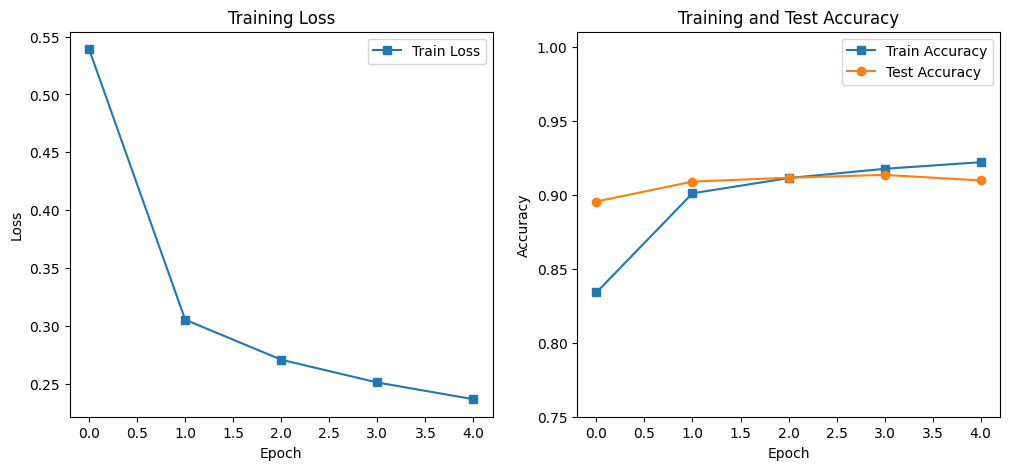

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_accuracy, "s-", label='Train Accuracy')
ax[1].plot(test_accuracy, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.75, 1.01)
ax[1].legend()

plt.show()

# Transfer learning EMNIST -> MNIST

In [12]:
mnist_data_train = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor()) 
mnist_data_test = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())    

batch_size = 32
mnist_train_dataloader = DataLoader(mnist_data_train, batch_size=batch_size, shuffle=True, drop_last=True)
mnist_test_dataloader = DataLoader(mnist_data_test, batch_size=batch_size, shuffle=False)

In [8]:
# Transfer learning
model_mnist = EMNIST_CNN()
model_mnist.load_state_dict(model.state_dict()) # load previous model

<All keys matched successfully>

In [9]:
print(model_mnist)

EMNIST_CNN(
  (encoder): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fnn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=294, out_features=50, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=50, out_features=26, bias=True)
  )
)


In [10]:
# change it to have 10 outputs instead of 26
# but this new layer will have weights that haven't been trained (random weights)
model_mnist.fnn[3] = torch.nn.Linear(in_features=50, out_features=10) 
print(model_mnist)

EMNIST_CNN(
  (encoder): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fnn): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=294, out_features=50, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=50, out_features=10, bias=True)
  )
)


# Now there are two options: 
1) Retrain all layers, normally using a smaller learning rate, that allows the CNN filters to "tweak" themselves specifically for digits, this is slower
2) Freeze the convolutional layers so only the new 10-way classifier learns. This is good if MNIST is a small dataset and it is also faster

In [20]:
# Option 1 -> Fine-tuning the whole CNN
model_mnist1 = EMNIST_CNN()
model_mnist1.load_state_dict(model.state_dict()) # load previous model
model_mnist1.fnn[3] = torch.nn.Linear(in_features=50, out_features=10) 

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mnist1.parameters(), lr=0.001)
epochs = 1

losses, train_accuracy, test_accuracy = train(model_mnist1, mnist_train_dataloader, mnist_test_dataloader, loss_fn, optimizer, device, epochs)

# with just one epoch we have 98% accuracy on the test set, but we have retrained the whole model

Epoch [1/1], Train Loss: 0.1658, Train Accuracy: 0.9510, Test Accuracy: 0.9802


In [21]:
# Option 2 -> Feature extraction
# Freeze the model, and just fine-tune the last layer

model_mnist2 = EMNIST_CNN()
model_mnist2.load_state_dict(model.state_dict()) # load previous model
model_mnist2.fnn[3] = torch.nn.Linear(in_features=50, out_features=10) 

for param in model_mnist2.encoder.parameters(): # freeze the weights in the encoder, not in the fnn
    param.requires_grad = False
    
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mnist2.parameters(), lr=0.001)
epochs = 1

losses, train_accuracy, test_accuracy = train(model_mnist2, mnist_train_dataloader, mnist_test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/1], Train Loss: 0.1547, Train Accuracy: 0.9535, Test Accuracy: 0.9829
